# Asking the Right Data Questions
## First Steps of Data Analytics

> **Disclaimer:** This notebook was generated with the assistance of AI and has been human-reviewed for accuracy and quality.

**Topics Covered:**
- Forming Questions  
- Proper data reporting  

## 1a. Forming Questions with Stakeholders

Effective data analytics begins long before any data is opened or queried. The most critical step is **forming the right questions alongside your stakeholders** — and doing so in a structured way.

---

### A. Context Setting — What Was Already Done?

Before jumping to new questions, establish shared ground. Understand what has already been measured, analyzed, or attempted. This prevents duplicating work and reveals gaps worth exploring.

Key questions to ask:
- What analyses or reports have already been run?
- What decisions were made based on previous data work?
- What did we learn, and what was left unanswered?

**Define KPI Ownership:**
As part of context setting, identify which KPI this stakeholder is *solely responsible for*. Knowing who owns what metric ensures that when a problem surfaces, we're solving it within the right scope — and not pulling in metrics that belong to another team or owner. Without clear ownership, problem scope expands quickly and accountability becomes unclear.

---

### B. What Do Our Goals Look Like?

Align with stakeholders on what success means *before* deciding what to measure. Vague goals produce vague questions, which produce misleading analyses.

Push for specificity:
- What outcome are we trying to improve or understand?
- How will we know if we're moving in the right direction?
- What does "good" look like six months from now?

**Define KPI Ownership:**
During goal alignment, confirm which specific KPI this stakeholder owns and is accountable for moving. Goals should map directly to that KPI — not to metrics owned by adjacent teams. This keeps the analysis focused and prevents scope creep when trying to solve an important problem. If a stakeholder's goal touches a metric they don't own, that's a flag to loop in the right owner before proceeding.

---

### C. What Does It Look Like When We Exceed Our Goals?

This is often overlooked — but defining what *overperformance* looks like is just as important as defining success. It helps distinguish signal from noise, and ensures the team can recognize a win when it happens.

Ask stakeholders:
- If we blew past our targets, what would that actually look like in the data?
- Are there scenarios where exceeding a goal could indicate a problem (e.g., a metric being gamed)?
- What would cause us to raise the bar?

---

### D. Which Data Sources Answer This Question?

> **The question must always come before the data source.**

It is tempting to start with the data you have and work backwards to a question it can answer. Resist this. That approach produces answers in search of a problem.

Instead:
1. Lock in the question with stakeholders first.
2. Then ask: *what data would actually answer this?*
3. Identify available sources — and be honest about gaps.
4. If the right data doesn't exist, that itself is a finding worth surfacing.

Letting data availability drive your questions leads to **availability bias** — you end up optimizing for what's easy to measure, not what actually matters

### Summary

| Step | Question to Ask | KPI Ownership |
|------|----------------|---------------|
| Context Setting | What has already been done? | Which KPI does this stakeholder own? |
| Goal Alignment | What does success look like? | Are goals tied to their owned KPI? |
| Defining Overperformance | What does exceeding our goals look like? | — |
| Data Sourcing | What data answers *this specific question*? | — |

The discipline of forming good questions with stakeholders is what separates meaningful analysis from noise. Start with the question. Always.

---

## 1b. Practice: Forming Questions from a Real Scenario

Now it's your turn. Read the following prompt carefully, then work through the question framework above to develop your analytical questions **before** touching any data.

---

### The Scenario

> You are a data analyst for an educational institution. The institution recently introduced **review sessions before exams** and wants to understand whether they are working. You have been given two text files:
> - `pre_review_grades.txt` — student exam grades **before** review sessions were introduced
> - `post_review_grades.txt` — student exam grades **after** review sessions were introduced

---

### Your Task

Using the framework from the section above, work through each step with this scenario in mind. Write your answers in the cells below each prompt.

**1. Context Setting — What do you already know?**
- Is there an analysis from the previous years? (pre-review grades from 2022, 2023, 2024, 2025)
    - how has grade collection changed from 2022 to 2025
- What kind of analysis have we performed with these grades previously? 
- Is the assessment the same from pre to post review?
    - pre_review (50 questions) post_review (25 questions). The effect of a shorter test + review session (2 variables)
    - What was the format of the exam??? Multiple choice? Long answer? Short answer? Oral exam? 
- Grade? Across grades or within 1 grade?
    - 1st graders to 12th graders? Just 3rd grade.

**2. Goal Alignment — What does success look like?**
- What are the schools important metrics needed for reporting/what is the expected outcome? 
- What is the most impactful thing we can work on? (Review sessions are effective). What is the least time consuming thing we can do to maximize impact (20% of 80%). 
- What will it look like for the review session to be effective?
    - Assumption: if effective, grades should be consistently higher. Metric?: Average (and also standard deviation)

**3. Defining Overperformance — What if results exceed expectations?**
- write questions here...

**4. Forming Your Core Question — Before you open the data**
- (review sessions + grades + success): Does the review session increase performance (grade average) on the assessment? 


In [8]:
# what is the first step that we should take to get all our python packages ready
import matplotlib.pyplot as plt
import statistics as stats

In [6]:
# begin exploring this data...

# read in text file
pre_review = open("data/pre_review_grades.txt")
post_review = open("data/post_review_grades.txt")

pre_data = pre_review.readlines()
post_data = post_review.readlines()

# pythonic line of code
# list comprehension
# [itr for itr in iterable] 
#  for e in pre_data (for-loop)...

# for-loop inside of a list --> list comprehension
#   iterate through an iterable and apply some sort of operation to each element
#   [iterator for iterator in iterable]
#   [func(iterator).method() for iterator in iterable]

# type-casting each element in the list (faster than just using a for-loop)

# one liner! 
clean_pre = [int(e) for e in pre_data]
clean_post = [int(post) for post in post_data]

print(clean_pre)
print(clean_post)

[94, 8, 20, 8, 96, 16, 69, 49, 41, 57, 35, 0, 56, 65, 71, 60, 89, 29, 39, 62, 74, 42, 41, 75, 82, 88, 34, 36, 29, 94, 29, 32, 15, 51, 4, 75, 33, 37, 15, 81, 32, 11, 93, 7, 75, 28, 99, 6, 91, 32, 77, 40, 79, 71, 58, 98, 35, 44, 19, 52, 39, 87, 96, 16, 56, 70, 12, 11, 97, 43, 46, 5, 97, 69, 77, 96, 27, 98, 100, 72, 8, 15, 60, 5, 60, 32, 22, 56, 86, 30, 82, 49, 31, 43, 30, 56, 33, 55, 10, 57]
[57, 54, 80, 100, 77, 72, 71, 53, 65, 62, 65, 71, 95, 65, 100, 55, 97, 76, 50, 78, 96, 95, 64, 61, 87, 73, 72, 68, 82, 52, 75, 71, 75, 78, 52, 74, 56, 60, 100, 64, 50, 54, 92, 89, 56, 58, 93, 96, 97, 60, 97, 88, 88, 88, 86, 56, 85, 66, 85, 95, 52, 67, 81, 86, 70, 60, 87, 62, 64, 66, 87, 99, 56, 67, 63, 94, 60, 57, 58, 84, 92, 91, 84, 94, 79, 89, 50, 68, 97, 62, 60, 70, 67, 77, 96, 87, 67, 95, 67, 97]


In [9]:
stats.mean(clean_pre)

50.12

In [14]:
stats.stdev(clean_pre)

29.160052929799132

In [10]:
stats.mean(clean_post)

74.86

In [13]:
stats.stdev(clean_post)

15.287824428530561

(array([ 6.,  3.,  7.,  2.,  9.,  4., 10.,  2.,  7.,  2.,  5.,  3.,  3.,
         2.,  8.,  5.,  3.,  3., 12.,  4.]),
 array([ 50. ,  52.5,  55. ,  57.5,  60. ,  62.5,  65. ,  67.5,  70. ,
         72.5,  75. ,  77.5,  80. ,  82.5,  85. ,  87.5,  90. ,  92.5,
         95. ,  97.5, 100. ]),
 <BarContainer object of 20 artists>)

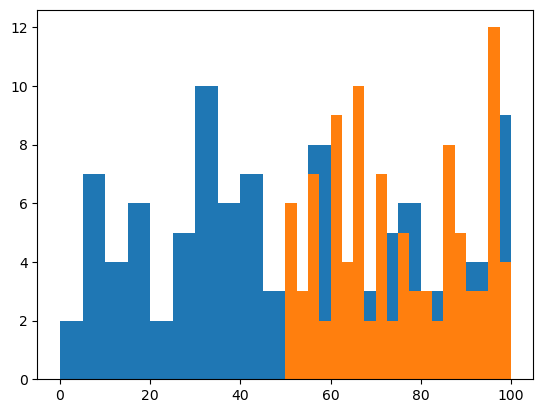

In [12]:
plt.hist(clean_pre, bins=20)
plt.hist(clean_post, bins=20)

Average grades increased (improvement) by almost 25 points! 

---

## 2a. Data Reporting

Once your analysis is complete, how you communicate your findings is just as important as the findings themselves. A well-executed analysis can lose all impact if it is reported vaguely, visually cluttered, or methodologically opaque. Good data reporting builds trust with stakeholders and enables confident decision-making.

---

### Be Specific

Vague reporting leaves room for misinterpretation and erodes credibility. Every claim in your report should be tied to a concrete number, timeframe, or population.

- **Don't say:** "Grades improved after the review sessions."
- **Do say:** "The average exam score increased from 71.4 to 79.8 (a 11.7% improvement) across 143 students in the Spring 2025 semester."

Specificity includes:
- The exact metric being reported (mean, median, pass rate, etc.)
- The time period and population the data covers
- The magnitude of change, not just the direction
- Any notable subgroups or exceptions worth calling out

---

### Use Helpful Visuals

A visual should make a finding *easier* to understand — not decorate a report. Choose your chart type based on what you are trying to show, and keep it clean.

| What You're Showing | Recommended Visual |
|---------------------|--------------------|
| Distribution of grades | Histogram or box plot |
| Before vs. after comparison | Side-by-side box plots or bar chart |
| Trend over time | Line chart |
| Composition (e.g., pass/fail split) | Stacked bar or pie chart (use sparingly) |

Tips for effective visuals:
- Always label axes with units
- Include a descriptive title that states the finding, not just the topic (e.g., *"Post-Review Scores Were Higher Across All Grade Bands"* rather than *"Grade Comparison"*)
- Avoid 3D charts, excessive color, or decorative elements that add no information
- If a table communicates the data more clearly than a chart, use a table

---

### Appropriately Discuss Inferential Statistics

Descriptive statistics tell you what happened in your data. Inferential statistics help you determine whether your findings are likely to hold beyond your sample — and they must be used carefully.

When reporting inferential results:
- **State your hypothesis clearly** before presenting test results. What were you testing for?
- **Report effect size alongside p-values.** A statistically significant result is not necessarily a meaningful one. A p-value tells you about likelihood; effect size tells you about magnitude.
- **Be honest about sample size.** Small samples can produce unreliable results even when statistical tests pass.
- **Do not overstate causation.** Unless your data comes from a controlled experiment, you are observing correlation. Say so explicitly.

> Example: *"A two-sample t-test found a statistically significant difference in mean scores (p = 0.03). However, with a Cohen's d of 0.21, the effect size is small, and further data collection is recommended before drawing strong conclusions."*

---

### Make Your Methodology Clear

Stakeholders should never have to guess how you arrived at your findings. A transparent methodology builds trust and makes your analysis reproducible.

Your report should answer:
- **What data did you use?** Source, date range, and any known limitations
- **How did you clean or filter the data?** Were any records excluded? Why?
- **What calculations or transformations did you apply?** Define your metrics explicitly
- **What assumptions did you make?** State them plainly so stakeholders can evaluate them
- **What are the limitations of this analysis?** Every analysis has them — name yours before someone else does

> Hiding your methodology does not make your findings stronger. It makes them harder to defend.

---

## 2b: Write a Data Report on the Review Session Analysis

You've already explored the `pre_review_grades.txt` and `post_review_grades.txt` data. Now use what you learned in Section 2a to write a short but complete data report on your findings.

Your report should be written as if you are presenting to the stakeholder at the educational institution — someone who needs to make a real decision about whether to continue, expand, or discontinue the review sessions.

---

### Your Report Must Include:

**1. A Specific Finding Statement**
State your main finding in one or two sentences. Include exact numbers — the before and after values, the magnitude of change, and the population your data covers. Do not use vague language like "grades went up."

**2. A Visual**
Choose one chart type from the table in Section 3 that best communicates your finding. Include it in your report and give it a descriptive title that states the finding, not just the topic.

---

> **Reminder:** A good report does not just show that something changed. It tells the stakeholder what the change means, how confident they should be in it, and what they should do next.

[write 1-2 sentences here]

---

## Exercise: Study Time Analysis

You have been given two new files:
- `pre_review_study_times.txt` — student study times **before** review sessions were introduced
- `post_review_study_times.txt` — student study times **after** review sessions were introduced

---

### Part 1: Form Your Questions

Before opening the files, work through the question framework from Section 1.

**Context Setting**
- write questions here...

**Goal Alignment**
- write questions here...

**Defining Overperformance**
- write questions here...

**Your Core Question**
- write questions here...

In [19]:
x = "5\t\t\n"

int(x)

5

In [15]:
# begin exploring this data...

# read in text file
pre_review = open("data/pre_review_study_times.txt")
post_review = open("data/post_review_study_times.txt")

pre_data = pre_review.readlines()
post_data = post_review.readlines()

# one liner! 
clean_pre = [float(e) for e in pre_data]
clean_post = [float(post) for post in post_data]

print(clean_pre)
print(clean_post)

[0.79, 4.62, 3.68, 4.83, 1.54, 2.88, 3.02, 3.49, 1.23, 3.75, 1.2, 3.72, 0.56, 2.72, 4.39, 4.39, 4.87, 3.51, 3.39, 3.82, 3.74, 2.91, 3.24, 2.21, 3.11, 2.87, 1.42, 2.46, 3.78, 3.84, 1.73, 1.55, 4.78, 2.53, 2.18, 1.35, 2.47, 2.08, 4.73, 2.25, 1.45, 0.62, 0.67, 4.84, 3.98, 1.97, 0.63, 3.48, 3.37, 3.13, 1.07, 1.24, 2.53, 4.96, 2.55, 0.71, 3.68, 3.74, 3.14, 2.8, 3.97, 0.73, 2.99, 2.7, 1.13, 2.82, 1.06, 3.32, 3.21, 1.79, 0.51, 2.42, 3.96, 2.62, 2.2, 3.98, 4.73, 2.85, 2.21, 3.96, 4.29, 4.37, 3.42, 4.81, 1.43, 4.41, 3.9, 3.92, 3.07, 2.65, 1.31, 0.9, 2.62, 1.1, 3.56, 0.54, 4.58, 2.84, 3.98, 1.02]
[4.79, 1.9, 2.32, 2.95, 2.32, 1.95, 1.15, 4.87, 2.5, 4.58, 3.46, 1.02, 5.35, 3.14, 5.81, 5.01, 4.75, 5.34, 3.77, 1.35, 2.82, 2.92, 3.88, 4.16, 1.73, 5.66, 4.54, 5.77, 4.12, 1.18, 5.87, 3.39, 5.93, 3.41, 4.88, 2.99, 2.8, 5.48, 3.96, 2.32, 6.0, 5.24, 1.75, 2.74, 4.07, 1.43, 4.21, 5.32, 3.42, 1.59, 3.16, 4.38, 3.65, 3.97, 5.39, 4.12, 3.73, 5.62, 3.08, 5.01, 1.68, 3.97, 1.13, 4.38, 3.44, 1.72, 4.31, 2.84, 1

### Part 2: Write Your Report

Using your findings from exploring the two study time files, write a complete data report following the Section 3 framework.

**1. Specific Finding Statement**
State your main finding with exact numbers. Include the before and after values, the size of the change, and the population the data covers.

**2. Visual**
Include a chart that best represents your finding. Give it a title that states the finding — not just "Study Time Comparison."

> **Remember:** Form the question first. Let the question determine which data you need — not the other way around.

[write 1-2 sentences here]